In [1]:
from fastai.vision.all import *
import numpy as np
import sys

np.set_printoptions(threshold=sys.maxsize)



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
import pandas as pd
import os
import random

# Keep original behavior: load labels, rename columns to id/value, drop known-bad cases
df = pd.read_csv(
    "../input/rsna-miccai-brain-tumor-radiogenomic-classification/train_labels.csv",
    header=0,
    names=["id", "value"],
    dtype=object,
)
df = df[~df.id.isin(["00109", "00123", "00709"])].reset_index(drop=True)



In [3]:
df.head()



,id,value
0,00642,0
1,00100,1
2,00309,0
3,00301,0
4,00464,0


In [4]:
# Fix: natural_sort used `re` but it was never imported.
import re


def natural_sort(l):
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split("([0-9]+)", key)]
    return sorted(l, key=alphanum_key)




In [5]:
import os
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
from tqdm import tqdm
from PIL import Image

INPUT = "../input/rsna-miccai-brain-tumor-radiogenomic-classification"

os.makedirs("./train", exist_ok=True)
os.makedirs("./test", exist_ok=True)


def process_dicom(path, outpath):
    # Fix: pydicom.read_file removed in pydicom>=3.0; use dcmread.
    dicom = pydicom.dcmread(path)

    data = apply_voi_lut(dicom.pixel_array, dicom)
    data = data.astype(np.float32)

    if getattr(dicom, "PhotometricInterpretation", "") == "MONOCHROME1":
        data = np.amax(data) - data

    data = data - np.min(data)
    mx = np.max(data)
    if mx > 0:
        data = data / mx
    data = (data * 255.0).clip(0, 255).astype(np.uint8)

    # Direct PIL conversion (avoids slow manual flattening)
    Image.fromarray(data, mode="L").save(outpath)


def get_mid_flair_dicom(subject_dir):
    """
    Fix logic: previously walked the whole tree and picked the middle file of *any* folder,
    often missing subject coverage and/or selecting non-FLAIR folders.
    Here we specifically target each subject's FLAIR folder and pick its middle DICOM.
    """
    flair_dir = os.path.join(subject_dir, "FLAIR")
    if not os.path.isdir(flair_dir):
        return None
    files = [f for f in os.listdir(flair_dir) if f.lower().endswith(".dcm")]
    if not files:
        return None
    files = natural_sort(files)
    mid = files[len(files) // 2]
    return os.path.join(flair_dir, mid)


def extract_mid_flair_pngs(input_dir, dataset="train"):
    base = os.path.join(input_dir, dataset)
    ids = natural_sort(
        [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
    )

    n_ok, n_skip = 0, 0
    for cur_id in tqdm(ids, desc=f"Extract {dataset} PNGs"):
        subject_dir = os.path.join(base, cur_id)
        dicom_path = get_mid_flair_dicom(subject_dir)
        if dicom_path is None:
            n_skip += 1
            continue
        outpath = os.path.join(f"./{dataset}", f"{cur_id}.png")
        if os.path.exists(outpath):
            n_ok += 1
            continue
        try:
            process_dicom(dicom_path, outpath)
            n_ok += 1
        except Exception:
            # If a rare corrupt file occurs, skip (train has known-bad cases excluded already)
            n_skip += 1

    print(f"{dataset}: wrote {n_ok} PNGs, skipped {n_skip}")


# Generate cached PNGs for train/test
extract_mid_flair_pngs(INPUT, "train")
extract_mid_flair_pngs(INPUT, "test")



Extract train PNGs:   0%|          | 0/527 [00:00<?, ?it/s]/tmp/ipykernel_11/3192803056.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(data, mode="L").save(outpath)
Extract train PNGs: 100%|██████████| 527/527 [00:46<00:00, 11.42it/s]


train: wrote 526 PNGs, skipped 1


Extract test PNGs: 100%|██████████| 60/60 [00:08<00:00,  6.86it/s]

test: wrote 59 PNGs, skipped 1


In [6]:
# Attach file paths; fix: ensure they exist and filter any missing (should be none after extraction)
df["file"] = df["id"].apply(lambda x: f"./train/{x}.png")
df = df[df["file"].apply(os.path.exists)].reset_index(drop=True)

# Ensure target is numeric for proper classification handling
df["value"] = df["value"].astype(int).astype(str)

df.head()



,id,value,file
0,00642,0,./train/00642.png
1,00100,1,./train/00100.png
2,00309,0,./train/00309.png
3,00301,0,./train/00301.png
4,00464,0,./train/00464.png


In [7]:
# Keep core approach: ImageDataLoaders.from_df with Resize(224), bs=64
# Fix: set y_block=CategoryBlock to do 2-class classification cleanly from string labels "0"/"1".
dls = ImageDataLoaders.from_df(
    df,
    item_tfms=Resize(224),
    bs=64,
    label_col=1,
    fn_col=2,
    path="",
    y_block=CategoryBlock,
)



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


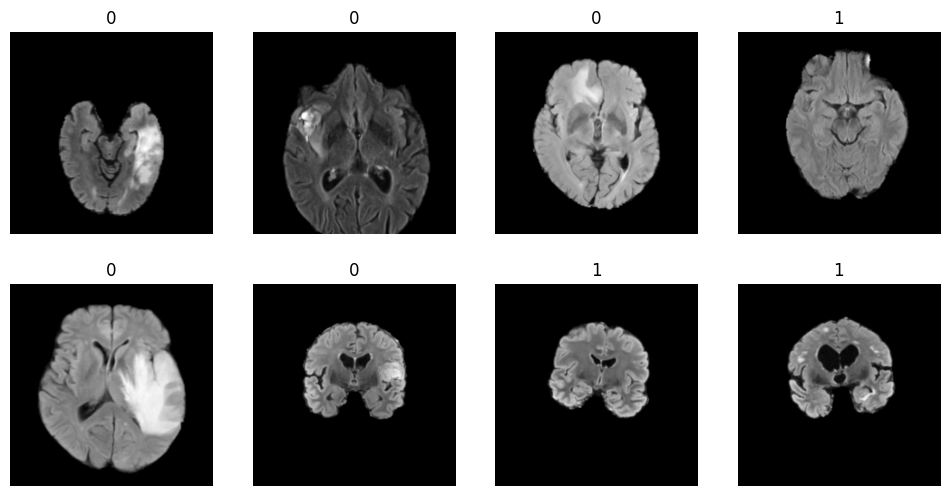

In [8]:
dls.show_batch(max_n=8)



In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        # Keep architecture; output size handled via cnn_learner's n_out below
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return x


print(Net())



Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [10]:
# Fix: ensure classification head output matches binary target so predict()[2][1] is valid.
# Keep your training loop and fp16 usage.
learn = cnn_learner(
    dls,
    Net,
    metrics=[error_rate, accuracy],
    model_dir="/tmp/model/",
    n_out=2,  # critical for binary probs
).to_fp16()



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


SuggestedLRs(valley=0.00363078061491251)

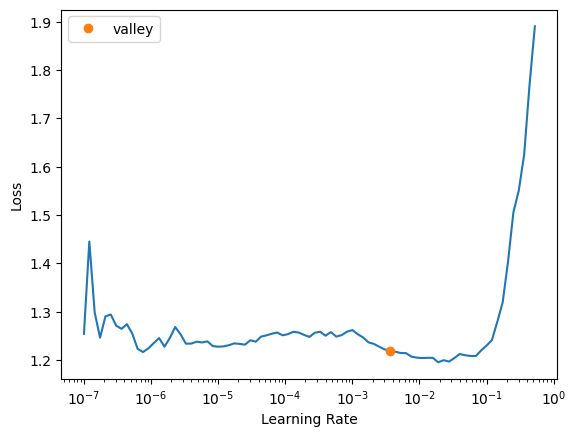

In [11]:
learn.lr_find()



In [12]:
learn.fit_one_cycle(10, lr_max=1e-2)



epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.180960,0.710312,0.442308,0.557692,00:00
1,1.119357,0.835538,0.557692,0.442308,00:00
2,1.107507,0.695561,0.442308,0.557692,00:00
3,1.056047,0.691583,0.461538,0.538462,00:00
4,1.063263,0.719899,0.576923,0.423077,00:00
5,1.040073,0.821914,0.557692,0.442308,00:00
6,1.035672,0.727199,0.490385,0.509615,00:00
7,1.013733,0.724434,0.548077,0.451923,00:00
8,0.990493,0.743174,0.596154,0.403846,00:00
9,0.994271,0.759308,0.596154,0.403846,00:00


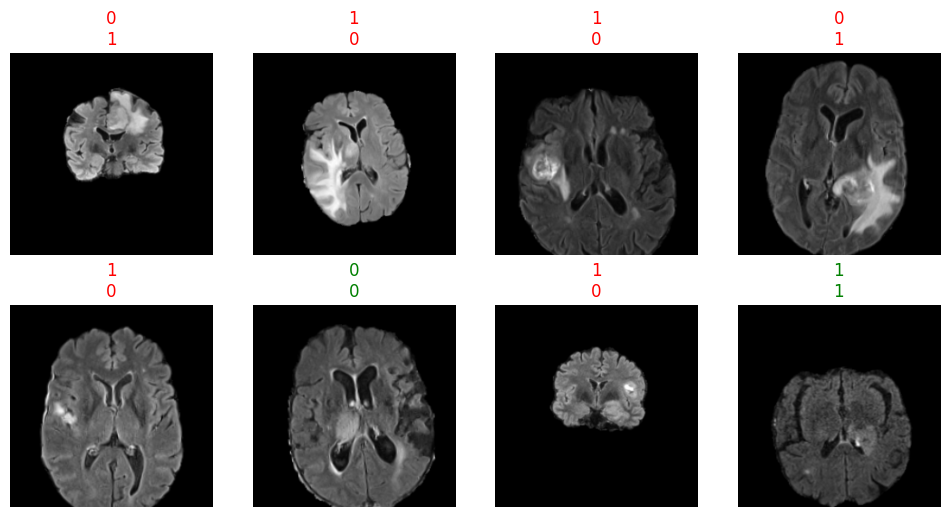

In [13]:
learn.show_results(max_n=8)



In [14]:
# Create test dataframe in the exact submission order to avoid row-count/id mismatches.
sample_sub = pd.read_csv(
    "../input/rsna-miccai-brain-tumor-radiogenomic-classification/sample_submission.csv",
    dtype={"BraTS21ID": str},
)
sample_sub["BraTS21ID"] = sample_sub["BraTS21ID"].astype(str).str.zfill(5)

df_test = pd.DataFrame({"id": sample_sub["BraTS21ID"].tolist(), "value": np.nan})

# Ensure all required test PNGs exist; if any missing, they will remain NaN and later filled with 0.5
missing = [i for i in df_test["id"] if not os.path.exists(f"./test/{i}.png")]
print(f"Missing test PNGs: {len(missing)}")



Missing test PNGs: 0


In [15]:
# Predict probabilities for class "1"
for id_num in tqdm(df_test.id.tolist(), desc="Predict test"):
    full_path = f"./test/{id_num}.png"
    if not os.path.exists(full_path):
        continue
    prediction = learn.predict(full_path)
    # prediction[2] is a tensor of probs aligned to dls.vocab
    # Find index of class "1" robustly (in case vocab order is ["1","0"]).
    vocab = list(dls.vocab)
    if "1" in vocab:
        idx1 = vocab.index("1")
    else:
        # fallback: assume positive class is second
        idx1 = 1
    probability = float(prediction[2][idx1].item())
    df_test.loc[df_test.id == id_num, "value"] = probability

# Fill any missing predictions with neutral probability
df_test["value"] = df_test["value"].astype(float).fillna(0.5)

df_test.head()



Predict test:   0%|          | 0/59 [00:00<?, ?it/s]

Predict test:  12%|█▏        | 7/59 [00:00<00:00, 64.36it/s]

Predict test:  27%|██▋       | 16/59 [00:00<00:00, 77.09it/s]

Predict test:  44%|████▍     | 26/59 [00:00<00:00, 83.04it/s]

Predict test:  61%|██████    | 36/59 [00:00<00:00, 85.95it/s]

Predict test:  76%|███████▋  | 45/59 [00:00<00:00, 87.11it/s]

Predict test:  92%|█████████▏| 54/59 [00:00<00:00, 87.98it/s]

Predict test: 100%|██████████| 59/59 [00:00<00:00, 85.04it/s]


,id,value
0,00356,0.626124
1,00140,0.335514
2,00757,0.552442
3,00275,0.603041
4,00570,0.654260


In [16]:
# Write submission with required columns and exact row count/order.
sub = df_test.rename(columns={"id": "BraTS21ID", "value": "MGMT_value"})
sub["BraTS21ID"] = sub["BraTS21ID"].astype(str).str.zfill(5)
sub.to_csv("submission.csv", index=False)

print(sub.shape)
print(sub.head())
print("Wrote submission.csv")

(59, 2)
  BraTS21ID  MGMT_value
0     00356    0.626124
1     00140    0.335514
2     00757    0.552442
3     00275    0.603041
4     00570    0.654260
Wrote submission.csv
